## Chapter 9 of *R for Data Science* (2e, 2023)

### 9.1.1

In [1]:
from hea import data
from hea.tidy import col

### 9.2

In [2]:
mpg = data("mpg", package="ggplot2")
mpg

manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
str,str,f64,i64,i64,str,str,i64,i64,str,str
"""audi""","""a4""",1.8,1999,4,"""auto(l5)""","""f""",18,29,"""p""","""compact"""
"""audi""","""a4""",1.8,1999,4,"""manual(m5)""","""f""",21,29,"""p""","""compact"""
"""audi""","""a4""",2.0,2008,4,"""manual(m6)""","""f""",20,31,"""p""","""compact"""
"""audi""","""a4""",2.0,2008,4,"""auto(av)""","""f""",21,30,"""p""","""compact"""
"""audi""","""a4""",2.8,1999,6,"""auto(l5)""","""f""",16,26,"""p""","""compact"""
…,…,…,…,…,…,…,…,…,…,…
"""volkswagen""","""passat""",2.0,2008,4,"""auto(s6)""","""f""",19,28,"""p""","""midsize"""
"""volkswagen""","""passat""",2.0,2008,4,"""manual(m6)""","""f""",21,29,"""p""","""midsize"""
"""volkswagen""","""passat""",2.8,1999,6,"""auto(l5)""","""f""",16,26,"""p""","""midsize"""


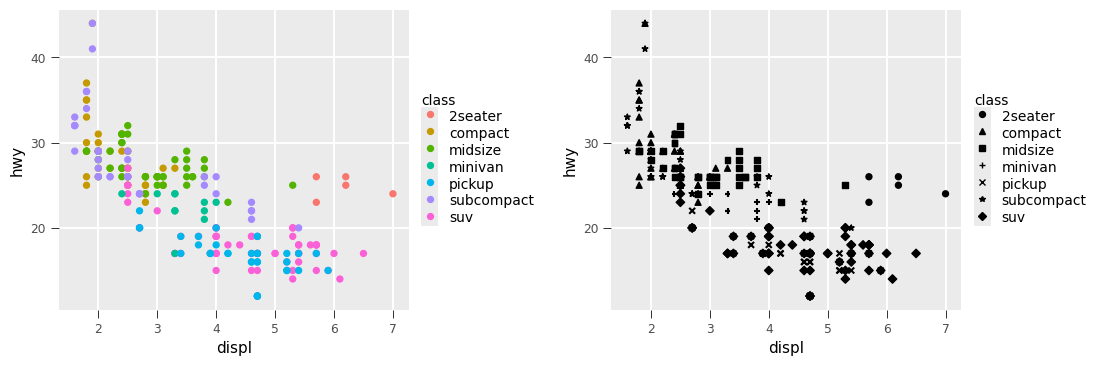

<Figure size 1085.25x351 with 0 Axes>

In [3]:
p1 = mpg.ggplot(x="displ", y="hwy", color="class").geom_point()
p2 = mpg.ggplot(x="displ", y="hwy", shape="class").geom_point()
p1 | p2

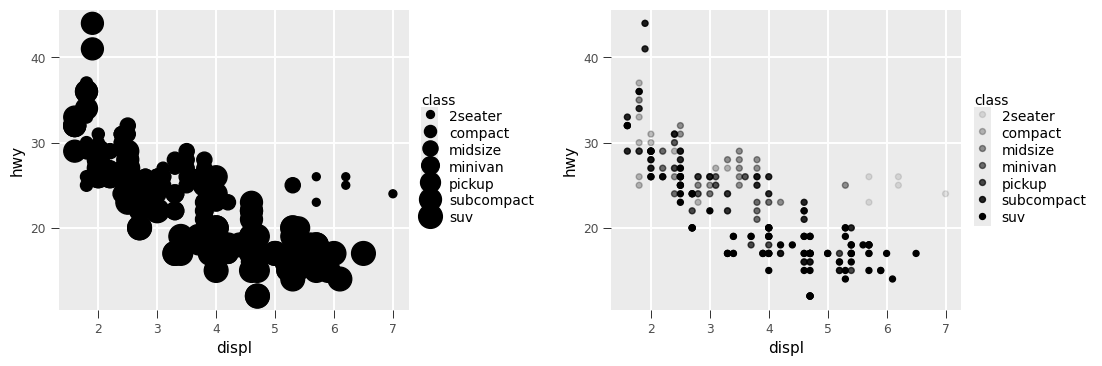

<Figure size 1085.25x351 with 0 Axes>

In [4]:
p1 = mpg.ggplot(x="displ", y="hwy", size="class").geom_point()
p2 = mpg.ggplot(x="displ", y="hwy", alpha="class").geom_point()
p1 | p2

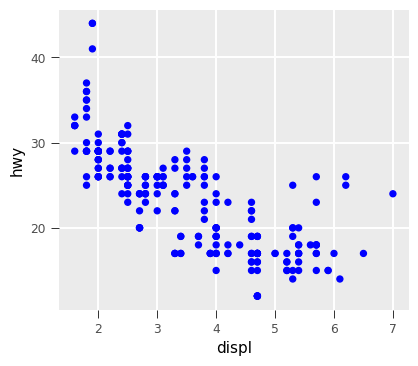

In [5]:
mpg.ggplot(x="displ", y="hwy").geom_point(color="blue")

### 9.3

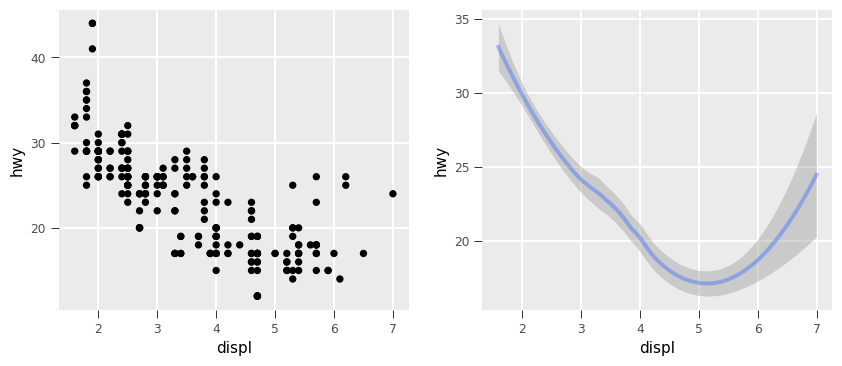

<Figure size 827.125x351 with 0 Axes>

In [6]:
p1 = mpg.ggplot(x="displ", y="hwy").geom_point()
p2 = mpg.ggplot(x="displ", y="hwy").geom_smooth()
p1 | p2

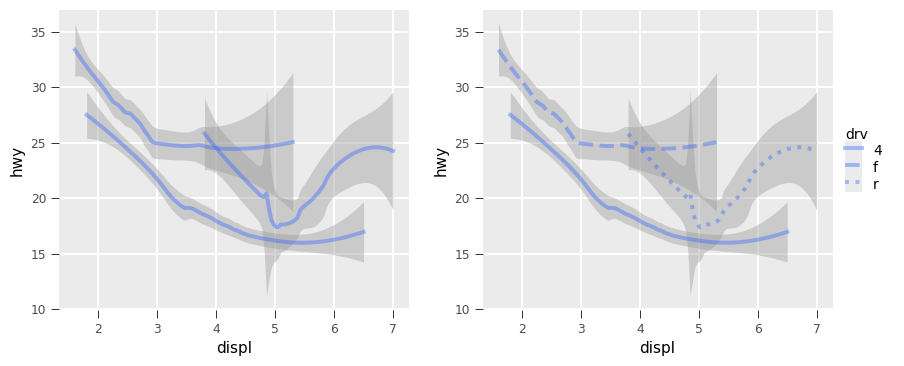

<Figure size 889x351 with 0 Axes>

In [7]:
p1 = mpg.ggplot(x="displ", y="hwy", shape="drv").geom_smooth()
p2 = mpg.ggplot(x="displ", y="hwy", linetype="drv").geom_smooth()
p1 | p2

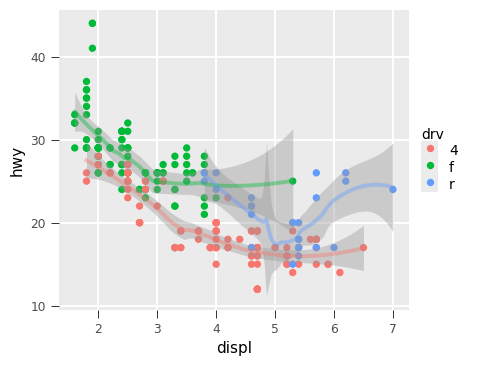

In [8]:
(
    mpg
        .ggplot(x="displ", y="hwy", color="drv")
        .geom_point()
        .geom_smooth(linestyle="drv")
)

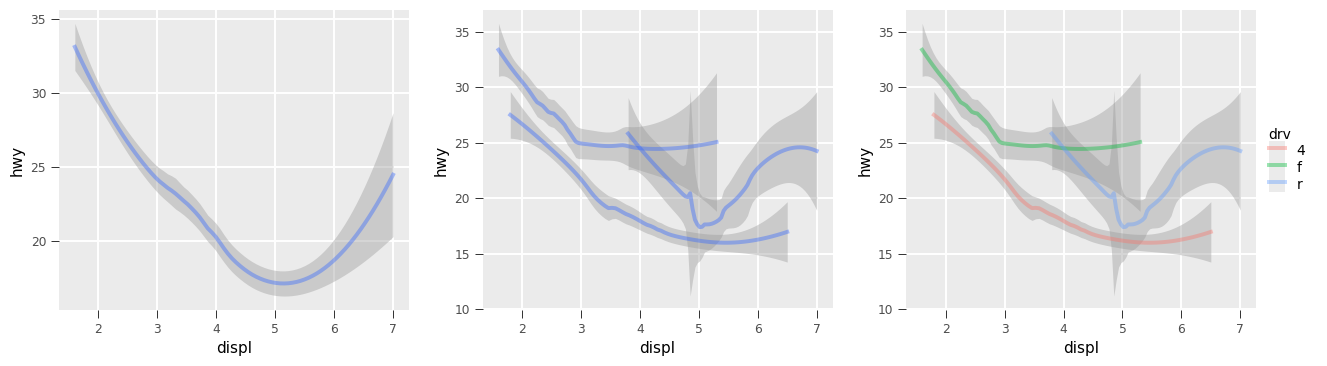

<Figure size 1312.63x351 with 0 Axes>

In [9]:
p1 = mpg.ggplot(x="displ", y="hwy").geom_smooth()
p2 = mpg.ggplot(x="displ", y="hwy").geom_smooth(group="drv")
p3 = mpg.ggplot(x="displ", y="hwy").geom_smooth(color="drv")
p1 | p2 | p3

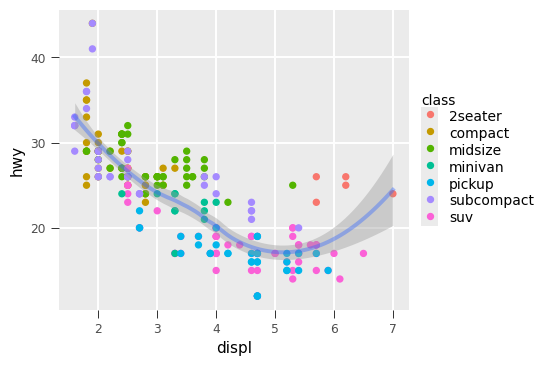

In [10]:
(
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point(color="class")
        .geom_smooth()        
)

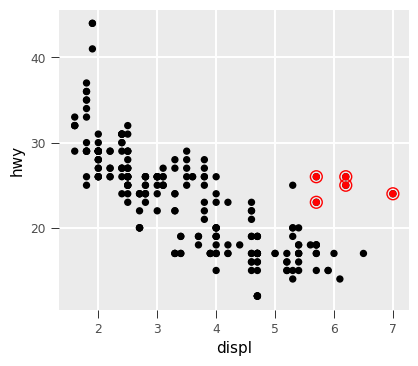

In [11]:
( 
   mpg
    .ggplot(x="displ", y="hwy")
    .geom_point()
    .geom_point(
        data=mpg.filter(col("class") == "2seater"),
        color="red"
    ).geom_point(
        data=mpg.filter(col("class") == "2seater"),
        shape="circle open", size=3, color='red'
    )
)

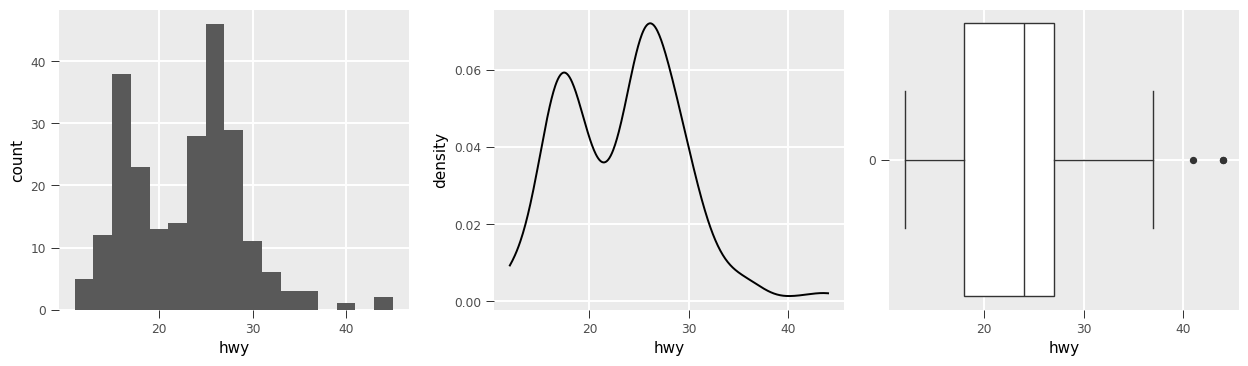

<Figure size 1233.38x351 with 0 Axes>

In [12]:
p1 = mpg.ggplot(x="hwy").geom_histogram(binwidth=2)
p2 = mpg.ggplot(x="hwy").geom_density()
p3 = mpg.ggplot(x="hwy").geom_boxplot()
p1 | p2 | p3

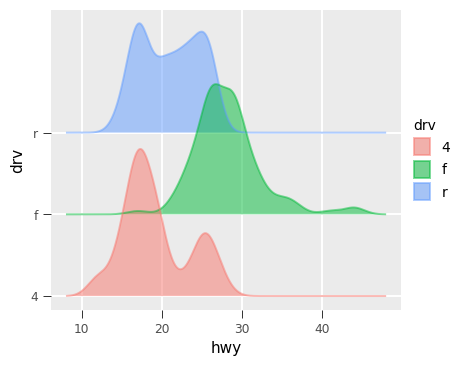

In [13]:
(
    mpg
        .ggplot(x="hwy", y="drv", fill="drv", color="drv")
        .geom_density_ridges(alpha=0.5)
)

### 9.4

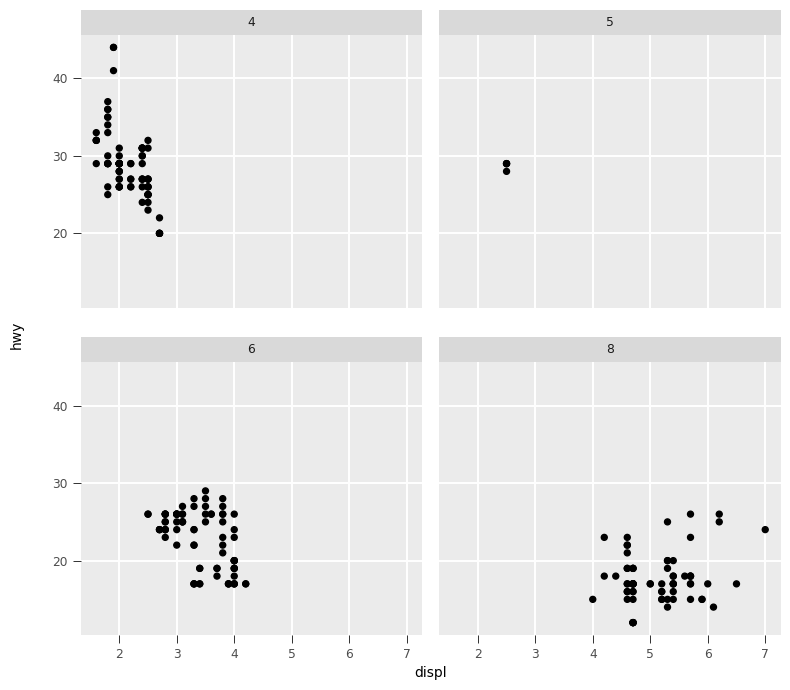

In [14]:
(
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point()
        .facet_wrap("~ cyl")
)

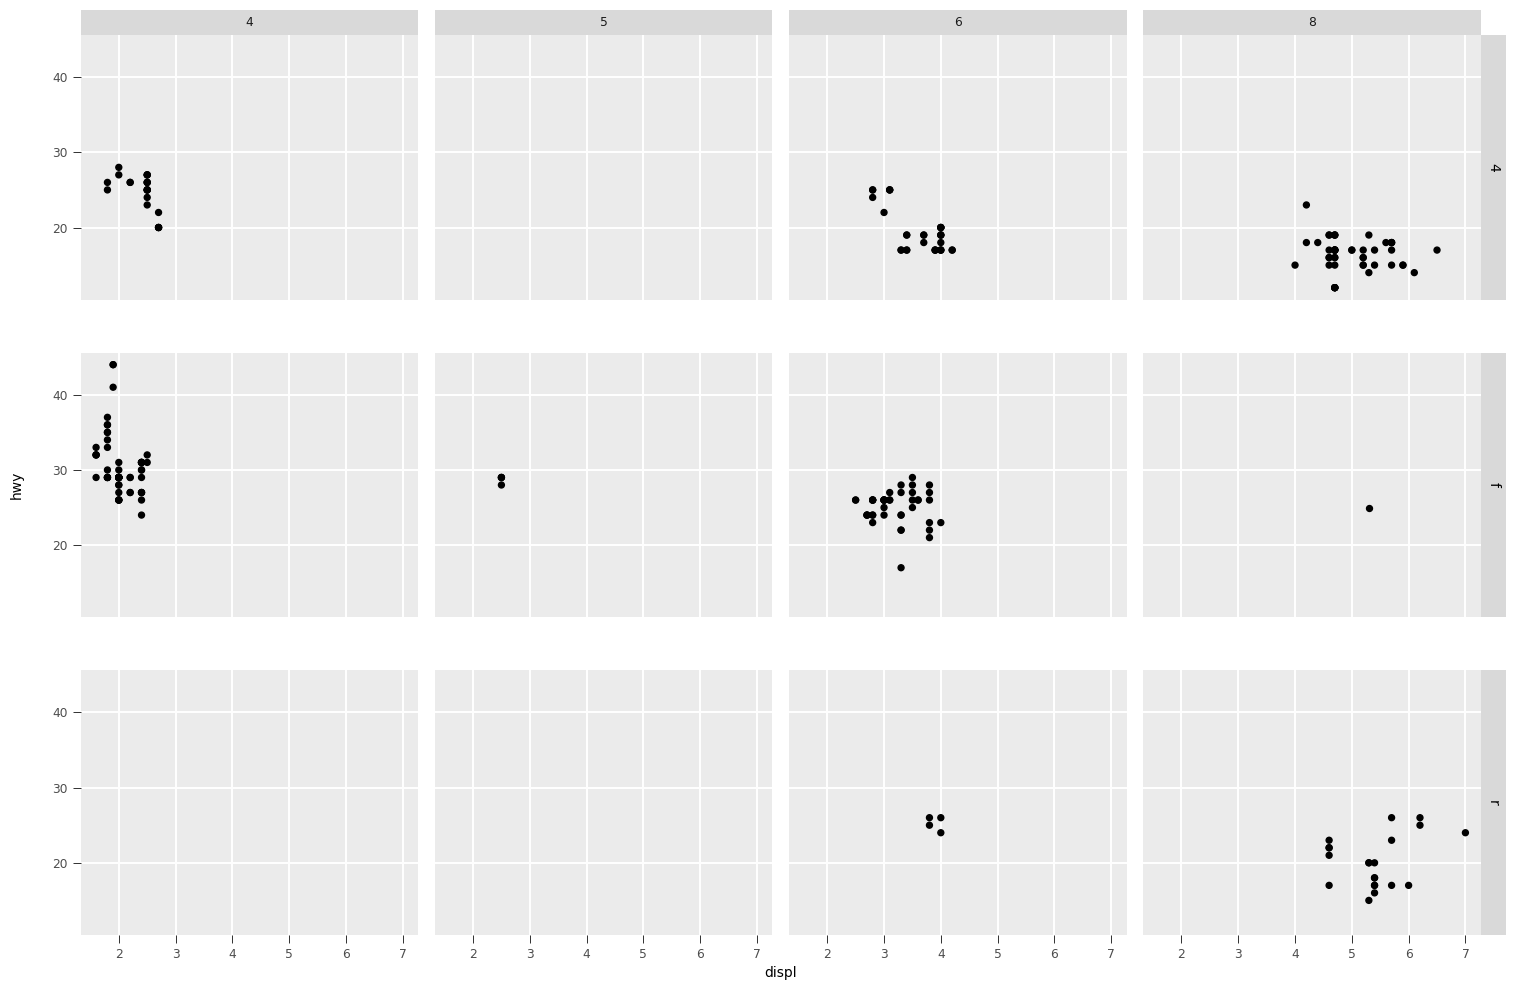

In [15]:
(
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point()
        .facet_grid("drv ~ cyl")
)

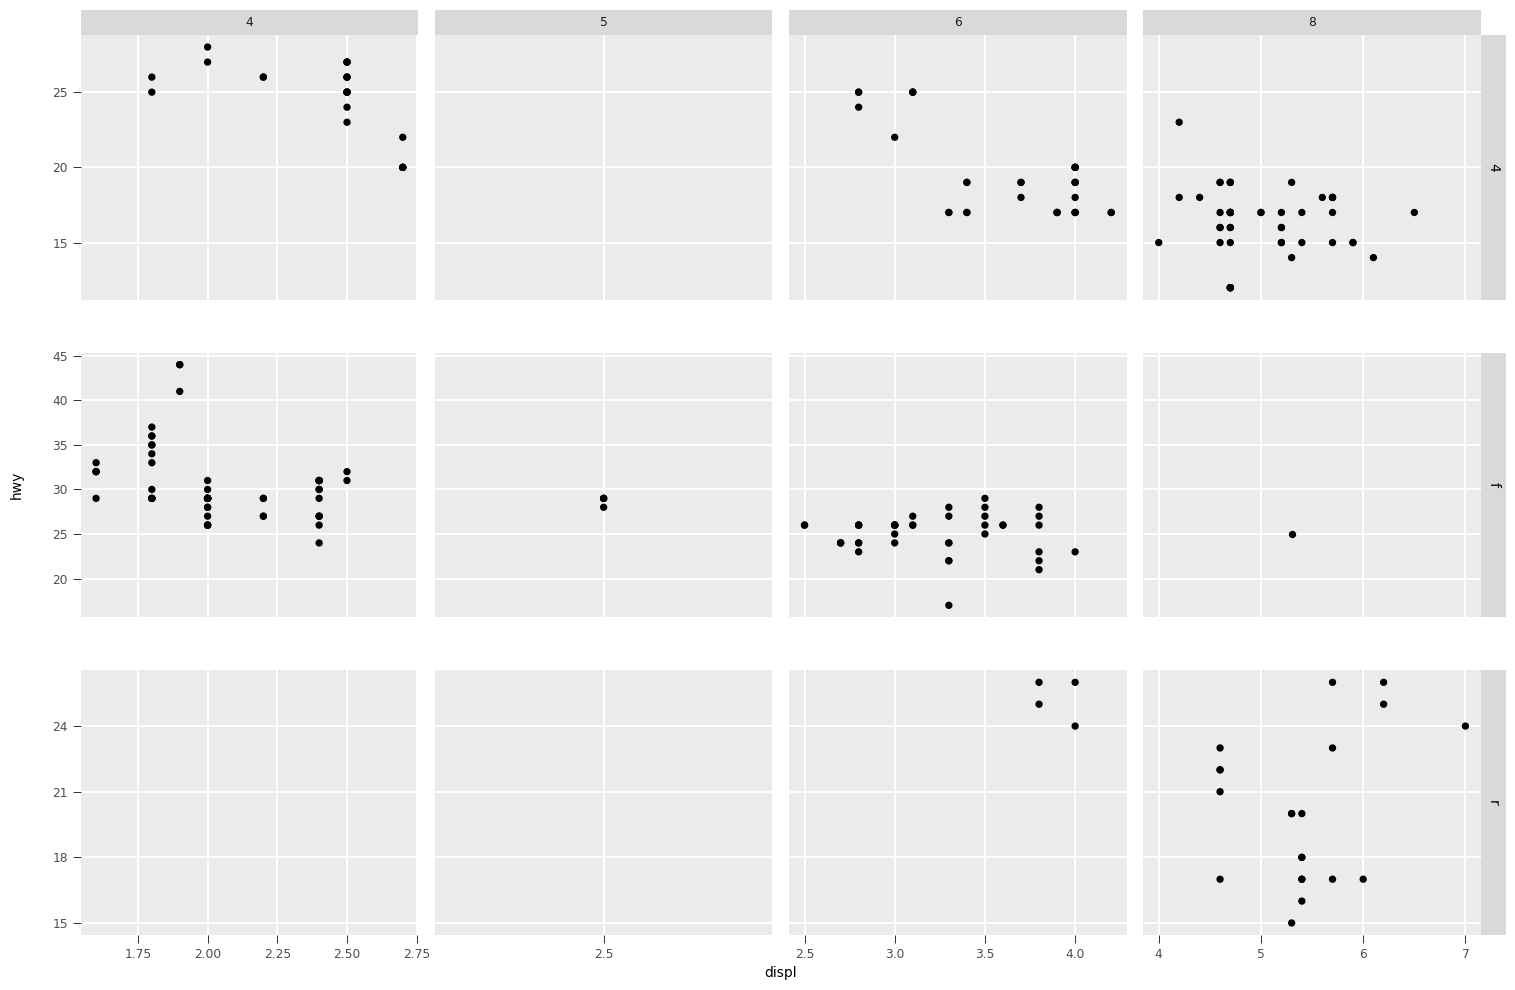

In [16]:
(
    mpg
        .ggplot(x="displ", y="hwy")
        .geom_point()
        .facet_grid("drv ~ cyl", scales='free')
)

### 9.5

In [17]:
diamonds = data("diamonds")
diamonds

carat,cut,color,clarity,depth,table,price,x,y,z
f64,enum,enum,enum,f64,f64,i64,f64,f64,f64
0.23,"""Ideal""","""E""","""SI2""",61.5,55.0,326,3.95,3.98,2.43
0.21,"""Premium""","""E""","""SI1""",59.8,61.0,326,3.89,3.84,2.31
0.23,"""Good""","""E""","""VS1""",56.9,65.0,327,4.05,4.07,2.31
0.29,"""Premium""","""I""","""VS2""",62.4,58.0,334,4.2,4.23,2.63
0.31,"""Good""","""J""","""SI2""",63.3,58.0,335,4.34,4.35,2.75
…,…,…,…,…,…,…,…,…,…
0.72,"""Ideal""","""D""","""SI1""",60.8,57.0,2757,5.75,5.76,3.5
0.72,"""Good""","""D""","""SI1""",63.1,55.0,2757,5.69,5.75,3.61
0.7,"""Very Good""","""D""","""SI1""",62.8,60.0,2757,5.66,5.68,3.56


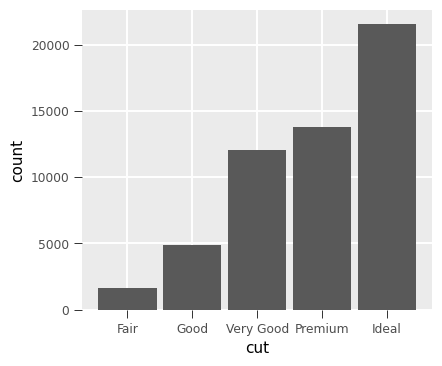

In [18]:
diamonds.ggplot(x="cut").geom_bar()

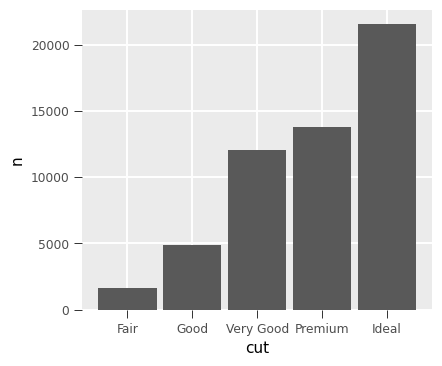

In [19]:
(
    diamonds
        .count("cut")
        .ggplot(x="cut", y="n")
        .geom_bar(stat="identity")
)

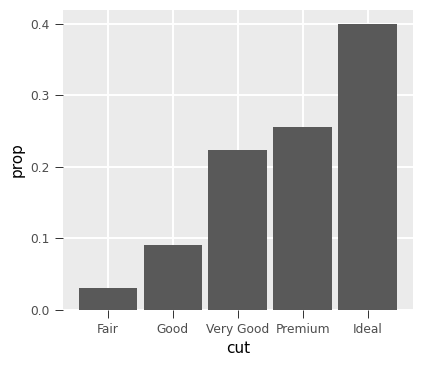

In [20]:
from hea.ggplot import after_stat
(
    diamonds
        .ggplot(x="cut", y=after_stat("prop"), group=1)
        .geom_bar()
)

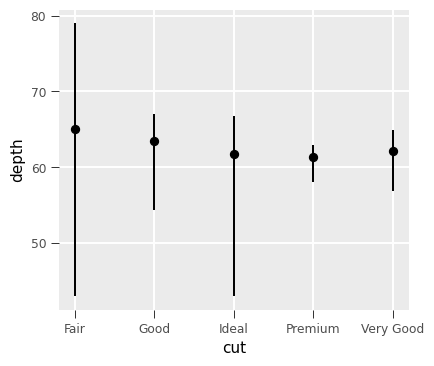

In [21]:
(
    diamonds
        .ggplot()
        .stat_summary(
            x="cut", y="depth",
            fun_min="min",
            fun_max="max",
            fun="median"
        )
)

### 9.6

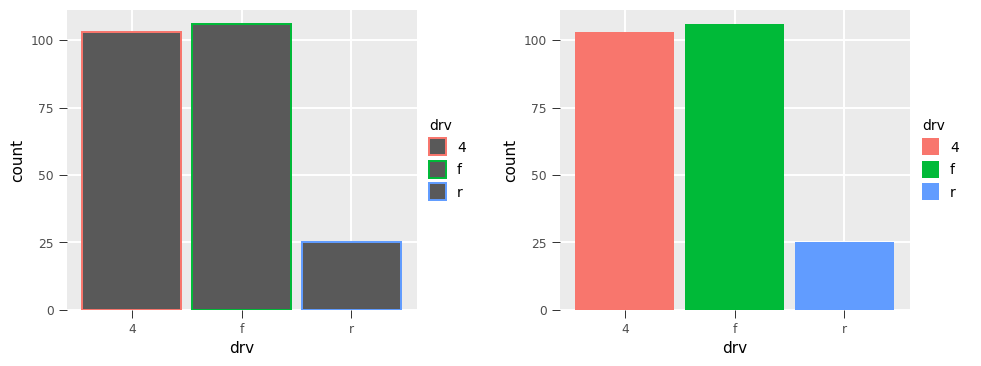

<Figure size 966x351 with 0 Axes>

In [22]:
p1 = mpg.ggplot(x="drv", color="drv").geom_bar()
p2 = mpg.ggplot(x="drv", fill="drv").geom_bar()
p1 + p2

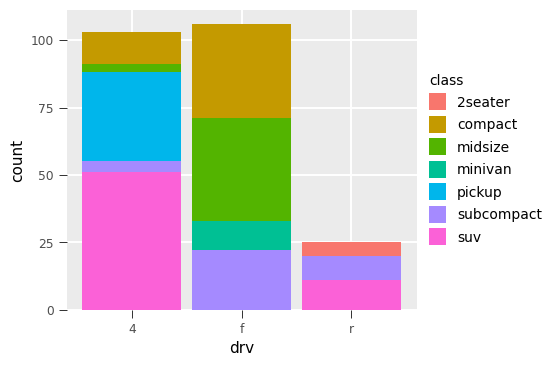

In [23]:
mpg.ggplot(x="drv", fill="class").geom_bar()

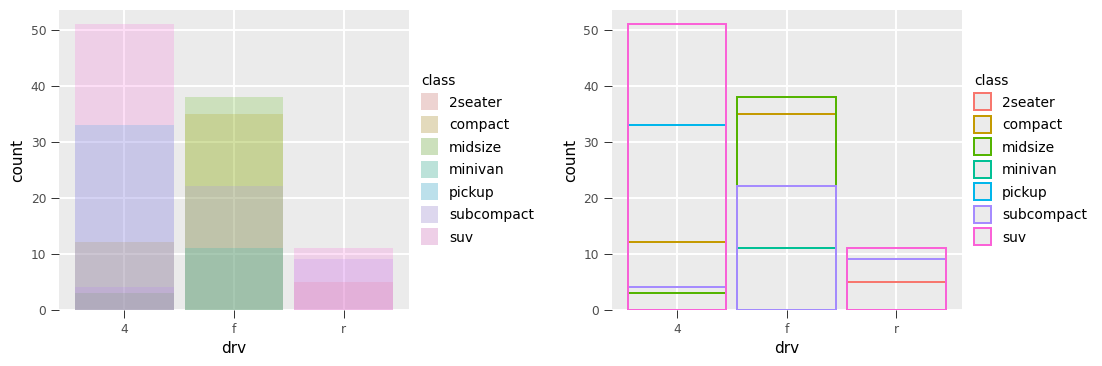

<Figure size 1085.5x351 with 0 Axes>

In [24]:
p1 = mpg.ggplot(x="drv", fill="class").geom_bar(alpha=1/5, position="identity")
p2 = mpg.ggplot(x="drv", color="class").geom_bar(fill=None, position="identity")
p1+p2

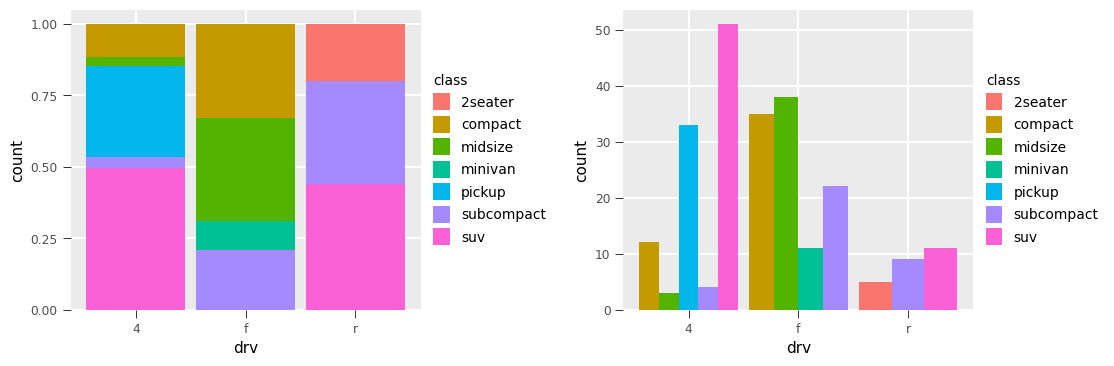

<Figure size 1097.13x351 with 0 Axes>

In [25]:
p1 = mpg.ggplot(x="drv", fill="class").geom_bar(position="fill")
p2 = mpg.ggplot(x="drv", fill="class").geom_bar(position="dodge")
p1+p2

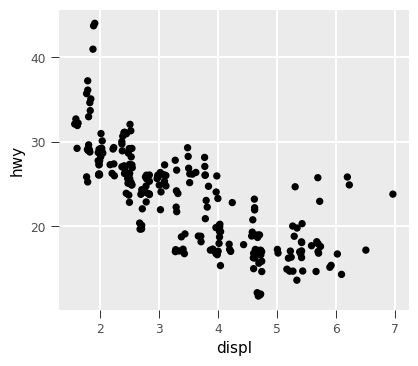

In [26]:
mpg.ggplot(x="displ", y="hwy").geom_point(position="jitter")

### 9.7

In [27]:
from hea import map_data

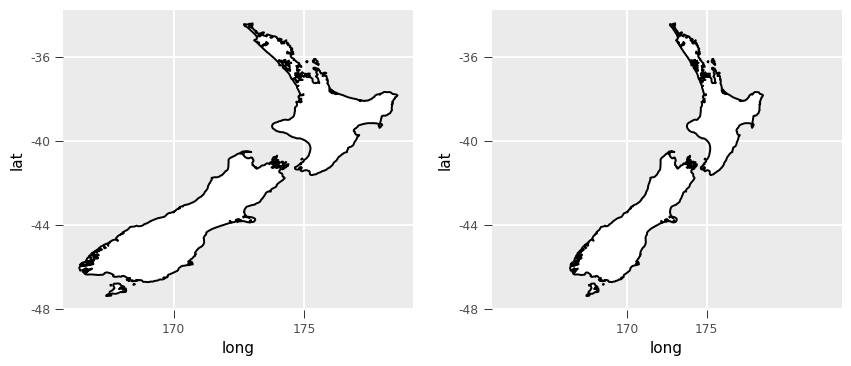

<Figure size 836.25x351 with 0 Axes>

In [28]:
nz = map_data("nz")
p1 = nz.ggplot(x="long", y = "lat", group = "group").geom_polygon(fill = "white", color = "black")

p2 = (
    nz
        .ggplot(x ="long", y="lat", group="group")
        .geom_polygon(fill = "white", color = "black")
        .coord_quickmap()        
)

p1 | p2

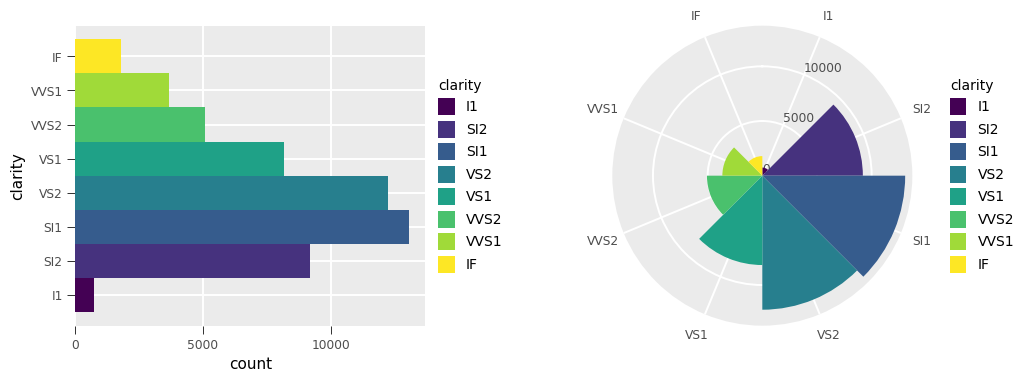

<Figure size 1024.75x351 with 0 Axes>

In [29]:
bar = (
    diamonds
        .ggplot()
        .geom_bar(x="clarity", fill="clarity", show_legend=True, width=1)
        .theme(aspect_ratio=1)
)

p1 = bar.coord_flip()
p2 = bar.coord_polar()
p1 | p2

In [30]:
from hea import session_info
session_info()

Python version 3.13.11 (CPython)
Platform: arm64-darwin25.4.0
Running under: macOS 26.4.1

BLAS:   accelerate
LAPACK: accelerate

locale: C.UTF-8

time zone: CEST

hea version 0.1.3

attached packages:
[1] IPython_9.13.0    hea_0.1.3         matplotlib_3.10.9 numpy_2.4.4
[5] pandas_3.0.2      polars_1.40.1     pyarrow_24.0.0    pytest_9.0.3
[9] scipy_1.17.1

loaded via a namespace (and not attached):
 [1] PIL_12.2.0              appnope_0.1.4           argparse_1.1
 [4] asttokens_3.0.1         comm_0.2.3              csv_1.0
 [7] ctypes_1.1.0            cycler_0.12.1           dateutil_2.9.0.post0
[10] debugpy_1.8.20          decimal_1.70            decorator_5.2.1
[13] defusedxml_0.7.1        executing_2.2.1         ipaddress_1.0
[16] ipykernel_7.2.0         jedi_0.19.2             json_2.0.9
[19] jupyter_client_8.8.0    jupyter_core_5.9.1      kiwisolver_1.5.0
[22] logging_0.5.1.2         matplotlib_inline_0.2.1 packaging_26.2
[25] parso_0.8.6             platform_1.0.8          plat